# Lab 09 — OpenSMILE: cechy głosu, wizualizacja i odszumianie

### Cel
Wyciągniesz cechy prozodyczne (pitch, jitter, shimmer/energy), zwizualizujesz je i sprawdzisz, jak zmieniają się po odszumianiu.

### Źródła
- OpenSMILE: https://audeering.github.io/opensmile/
- Wrapper: https://github.com/audeering/opensmile-python

### Instalacja w Colab

In [12]:
import matplotlib.pyplot as plt
plt.style.use("default")

In [2]:
url = '/home/dom/Music/rec/nieduzodzwieku.wav'


In [3]:
# Preferowany wrapper Python
# !pip -q install opensmile
import opensmile, librosa, numpy as np, pandas as pd
from matplotlib import pyplot as plt

# TODO: wczytaj audio i ekstraktuj cechy z konfiguracji GeMAPS
smile = opensmile.Smile(feature_set=opensmile.FeatureSet.GeMAPS, feature_level=opensmile.FeatureLevel.Functionals)
features = smile.process_file(url)
features.head()


/home/dom/python_global_venvs/ML/venv/lib64/python3.11/site-packages/opensmile/core/smile.py:252: UserWarning: Feature set 'FeatureSet.GeMAPS' is deprecated, consider switching to 'FeatureSet.GeMAPSv01b'.
  warnings.warn(


,,,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope,...,alphaRatioUV_sma3nz_amean,hammarbergIndexUV_sma3nz_amean,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength
file,start,end,,,,,,,,,,,,,,,,,,,,,
/home/dom/Music/rec/nieduzodzwieku.wav,0 days,0 days 00:00:05.310952381,27.789305,0.155135,24.872534,27.186615,32.384899,7.512365,75.133995,58.21579,195.578323,286.833466,...,-8.706744,15.424523,-0.005064,-0.019412,6.792453,1.717557,0.528889,0.542186,0.03625,0.015762


In [34]:
features = smile.process_file("/home/dom/Music/rec/nieduzodzwieku.wav")
important_cols = [
    'F0semitoneFrom27.5Hz_sma3nz_amean',  # Średnia częstotliwość podstawowa (wysokość głosu)
    'jitterLocal_sma3nz_amean',           # Jitter (stabilność drgań - biomarker zdrowia)
    'shimmerLocaldB_sma3nz_amean',        # Shimmer (stabilność amplitudy)
    'loudness_sma3_amean',                # Średnia głośność
    'alphaRatioV_sma3nz_amean'            # Stosunek energii (barwa głosu)
]
features[important_cols].T

file,/home/dom/Music/rec/nieduzodzwieku.wav
start,0 days
end,0 days 00:00:05.310952381
F0semitoneFrom27.5Hz_sma3nz_amean,27.789305
jitterLocal_sma3nz_amean,0.058971
shimmerLocaldB_sma3nz_amean,1.409566
loudness_sma3_amean,1.996051
alphaRatioV_sma3nz_amean,-11.899901


In [35]:
features = smile.process_file("/home/dom/Music/rec/alamakota.wav")
important_cols = [
    'F0semitoneFrom27.5Hz_sma3nz_amean',  # Średnia częstotliwość podstawowa (wysokość głosu)
    'jitterLocal_sma3nz_amean',           # Jitter (stabilność drgań - biomarker zdrowia)
    'shimmerLocaldB_sma3nz_amean',        # Shimmer (stabilność amplitudy)
    'loudness_sma3_amean',                # Średnia głośność
    'alphaRatioV_sma3nz_amean'            # Stosunek energii (barwa głosu)
]
features[important_cols].T

file,/home/dom/Music/rec/alamakota.wav
start,0 days
end,0 days 00:00:04.124149660
F0semitoneFrom27.5Hz_sma3nz_amean,29.208899
jitterLocal_sma3nz_amean,0.071490
shimmerLocaldB_sma3nz_amean,1.370398
loudness_sma3_amean,1.124995
alphaRatioV_sma3nz_amean,-11.760464


In [36]:
features = smile.process_file("/home/dom/Music/rec/mikbezpopfiltra.wav")
important_cols = [
    'F0semitoneFrom27.5Hz_sma3nz_amean',  # Średnia częstotliwość podstawowa (wysokość głosu)
    'jitterLocal_sma3nz_amean',           # Jitter (stabilność drgań - biomarker zdrowia)
    'shimmerLocaldB_sma3nz_amean',        # Shimmer (stabilność amplitudy)
    'loudness_sma3_amean',                # Średnia głośność
    'alphaRatioV_sma3nz_amean'            # Stosunek energii (barwa głosu)
]
features[important_cols].T

file,/home/dom/Music/rec/mikbezpopfiltra.wav
start,0 days
end,0 days 00:00:08.786507937
F0semitoneFrom27.5Hz_sma3nz_amean,26.975668
jitterLocal_sma3nz_amean,0.064146
shimmerLocaldB_sma3nz_amean,1.457635
loudness_sma3_amean,1.644720
alphaRatioV_sma3nz_amean,-12.011776


### Wizualizacja i porównanie przed/po odszumianiu

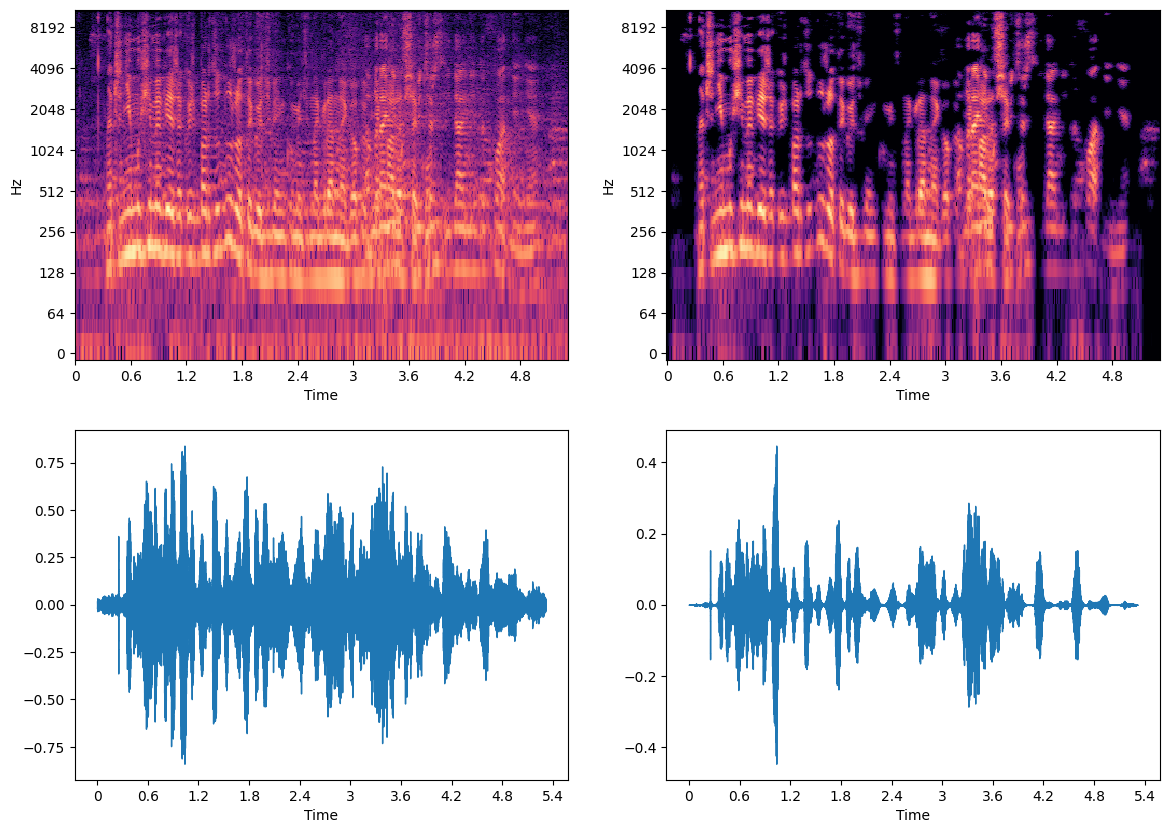

In [15]:
# !pip -q install noisereduce
import noisereduce as nr
y, fs = librosa.load(url)

y_clean = nr.reduce_noise(y=y, sr=fs)
features_clean = smile.process_signal(y_clean, fs)

# Porównaj wykresy (np. energy, F0)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# TODO: policz i narysuj spektrogram (STFT)
S = np.abs(librosa.stft(y, n_fft=1024, hop_length=256))
S_clean = np.abs(librosa.stft(y_clean, n_fft=1024, hop_length=256))
librosa.display.specshow(librosa.amplitude_to_db(S, ref=np.max), sr=fs, hop_length=256, x_axis='time', y_axis='log', ax=axs[0, 0])
librosa.display.specshow(librosa.amplitude_to_db(S_clean, ref=np.max), sr=fs, hop_length=256, x_axis='time', y_axis='log', ax=axs[0, 1])

librosa.display.waveshow(y, ax=axs[1, 0])
librosa.display.waveshow(y_clean, ax=axs[1, 1])

In [32]:
from IPython.display import Audio
audio = Audio(url)
audio